<a href="https://colab.research.google.com/github/onon1999/Mahir/blob/main/AirBNB%20price%20prediction%20RAWDATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
file_path = "/content/airbnb (1).csv"
df = pd.read_csv(file_path)

# Display basic info and first few rows
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    12805 non-null  int64  
 1   id            12805 non-null  int64  
 2   name          12805 non-null  object 
 3   rating        12805 non-null  object 
 4   reviews       12805 non-null  object 
 5   host_name     12797 non-null  object 
 6   host_id       12805 non-null  float64
 7   address       12805 non-null  object 
 8   features      12805 non-null  object 
 9   amenities     12805 non-null  object 
 10  safety_rules  12805 non-null  object 
 11  hourse_rules  12805 non-null  object 
 12  img_links     12805 non-null  object 
 13  price         12805 non-null  int64  
 14  country       12805 non-null  object 
 15  bathrooms     12805 non-null  int64  
 16  beds          12805 non-null  int64  
 17  guests        12805 non-null  int64  
 18  toiles        12805 non-nu

(None,
    Unnamed: 0        id                                               name  \
 0           0  49849504                                     Perla bungalov   
 1           1  50891766  Authentic Beach Architect Sheltered Villa with...   
 2           2  50699164                                  cottages sataplia   
 3           3  49871422                        Sapanca Breathable Bungalow   
 4           4  51245886                                      Bungalov Ev 2   
 
   rating reviews    host_name      host_id                   address  \
 0   4.71      64    Mehmetcan  357334205.0  Kartepe, Kocaeli, Turkey   
 1    New       0        Fatih  386223873.0      Kaş, Antalya, Turkey   
 2   4.85      68       Giorgi  409690853.0          Imereti, Georgia   
 3    5.0      13        Melih  401873242.0  Sapanca, Sakarya, Turkey   
 4    New       0  Arp Sapanca  414884116.0  Sapanca, Sakarya, Turkey   
 
                                  features  \
 0    2 guests,2 bedrooms,1 bed

In [2]:
# Drop unnecessary columns
df.drop(columns=["Unnamed: 0", "id", "host_id", "host_name", "img_links", "checkin", "checkout"], inplace=True)

# Convert 'rating' to numeric (replace 'New' with NaN first)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Convert 'reviews' to numeric
df["reviews"] = pd.to_numeric(df["reviews"], errors="coerce")

# Handle missing values: Fill numeric columns with median and categorical with mode
numeric_cols = ["rating", "reviews"]
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Extract numerical values from 'features' column
df["guests"] = df["features"].str.extract(r"(\d+) guests").astype(float)
df["bedrooms"] = df["features"].str.extract(r"(\d+) bedroom").astype(float)
df["beds"] = df["features"].str.extract(r"(\d+) bed").astype(float)
df["bathrooms"] = df["features"].str.extract(r"(\d+) bathroom").astype(float)

# Convert 'amenities' into count of amenities
df["amenities_count"] = df["amenities"].apply(lambda x: len(x.split(",")) if isinstance(x, str) else 0)

# Convert 'address' into country-based encoding
df["country"] = df["country"].astype("category").cat.codes

# Drop 'features' and 'amenities' as they have been processed
df.drop(columns=["features", "amenities"], inplace=True)

# Display the cleaned dataset structure
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             12805 non-null  object 
 1   rating           12805 non-null  float64
 2   reviews          12805 non-null  float64
 3   address          12805 non-null  object 
 4   safety_rules     12805 non-null  object 
 5   hourse_rules     12805 non-null  object 
 6   price            12805 non-null  int64  
 7   country          12805 non-null  int16  
 8   bathrooms        9641 non-null   float64
 9   beds             12765 non-null  float64
 10  guests           12678 non-null  float64
 11  toiles           12805 non-null  int64  
 12  bedrooms         12113 non-null  float64
 13  studios          12805 non-null  int64  
 14  amenities_count  12805 non-null  int64  
dtypes: float64(6), int16(1), int64(4), object(4)
memory usage: 1.4+ MB


(None,
                                                 name  rating  reviews  \
 0                                     Perla bungalov    4.71     64.0   
 1  Authentic Beach Architect Sheltered Villa with...    4.89      0.0   
 2                                  cottages sataplia    4.85     68.0   
 3                        Sapanca Breathable Bungalow    5.00     13.0   
 4                                      Bungalov Ev 2    4.89      0.0   
 
                     address  \
 0  Kartepe, Kocaeli, Turkey   
 1      Kaş, Antalya, Turkey   
 2          Imereti, Georgia   
 3  Sapanca, Sakarya, Turkey   
 4  Sapanca, Sakarya, Turkey   
 
                                         safety_rules  \
 0  󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...   
 1  󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...   
 2  󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...   
 3  󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...   
 4  󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...   
 
         

In [3]:
# Fill missing values with median of respective columns
df["bathrooms"].fillna(df["bathrooms"].median(), inplace=True)
df["beds"].fillna(df["beds"].median(), inplace=True)
df["guests"].fillna(df["guests"].median(), inplace=True)
df["bedrooms"].fillna(df["bedrooms"].median(), inplace=True)

# Confirm all missing values are handled
df.isnull().sum()


<ipython-input-3-afdf14f0feb3>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bathrooms"].fillna(df["bathrooms"].median(), inplace=True)
<ipython-input-3-afdf14f0feb3>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,0
name,0
rating,0
reviews,0
address,0
safety_rules,0
hourse_rules,0
price,0
country,0
bathrooms,0
beds,0


In [4]:
# Function to handle outliers using the IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define acceptable range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers instead of removing them
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

# Apply outlier handling to key numerical columns
outlier_columns = ["price", "rating", "reviews", "bathrooms", "beds", "guests", "bedrooms", "amenities_count"]
for col in outlier_columns:
    remove_outliers(df, col)

# Verify changes by checking summary statistics
df.describe()


,rating,reviews,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,amenities_count
count,12805.000000,12805.000000,12805.000000,12805.000000,12805.000000,12805.000000,12805.000000,12805.000000,12805.000000,12805.000000,12805.0
mean,4.875502,27.170832,11748.965248,59.654432,2.353143,2.060601,4.993987,0.019211,2.015619,0.023585,10.0
std,0.093889,34.519239,10216.770226,29.829763,1.554666,1.473206,3.160506,0.137272,1.467147,0.151757,0.0
min,4.680000,0.000000,393.000000,0.000000,0.000000,1.000000,2.000000,0.000000,1.000000,0.000000,10.0
25%,4.830000,1.000000,3994.000000,43.000000,1.000000,1.000000,2.000000,0.000000,1.000000,0.000000,10.0
50%,4.890000,10.000000,8175.000000,47.000000,2.000000,1.000000,4.000000,0.000000,1.000000,0.000000,10.0
75%,4.930000,42.000000,16062.000000,90.000000,3.000000,3.000000,6.000000,0.000000,3.000000,0.000000,10.0
max,5.000000,103.500000,34164.000000,147.000000,6.000000,6.000000,12.000000,1.000000,6.000000,1.000000,10.0


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features and target variable
features = ["rating", "reviews", "country", "bathrooms", "beds", "guests", "bedrooms", "amenities_count"]
target = "price"

X = df[features]
y = df[target]

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Linear Regression model as a baseline
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions and performance evaluation
y_pred = lr_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

(mae, rmse, r2)


(6554.417819429364, 8706.792710800783, 0.256474895280533)

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, r2_score
# Define ANN model architecture
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)  # Output layer (predicting price)
])

# Compile the model
ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = ann_model.fit(X_train_scaled, y_train, epochs=200, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=0)



# ... (rest of the code from the previous response) ...

# Evaluate performance
ann_loss, ann_mae = ann_model.evaluate(X_test_scaled, y_test, verbose=0)

# Predict on the test set
y_pred_ann = ann_model.predict(X_test_scaled)

# Calculate MSE and R-squared
ann_mse = mean_squared_error(y_test, y_pred_ann)
ann_r2 = r2_score(y_test, y_pred_ann)

# Print the results
print(f"ANN MAE: {ann_mae}")
print(f"ANN MSE: {ann_mse}")
print(f"ANN R-squared: {ann_r2}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN MAE: 6209.76708984375
ANN MSE: 68393352.0
ANN R-squared: 0.3291998505592346


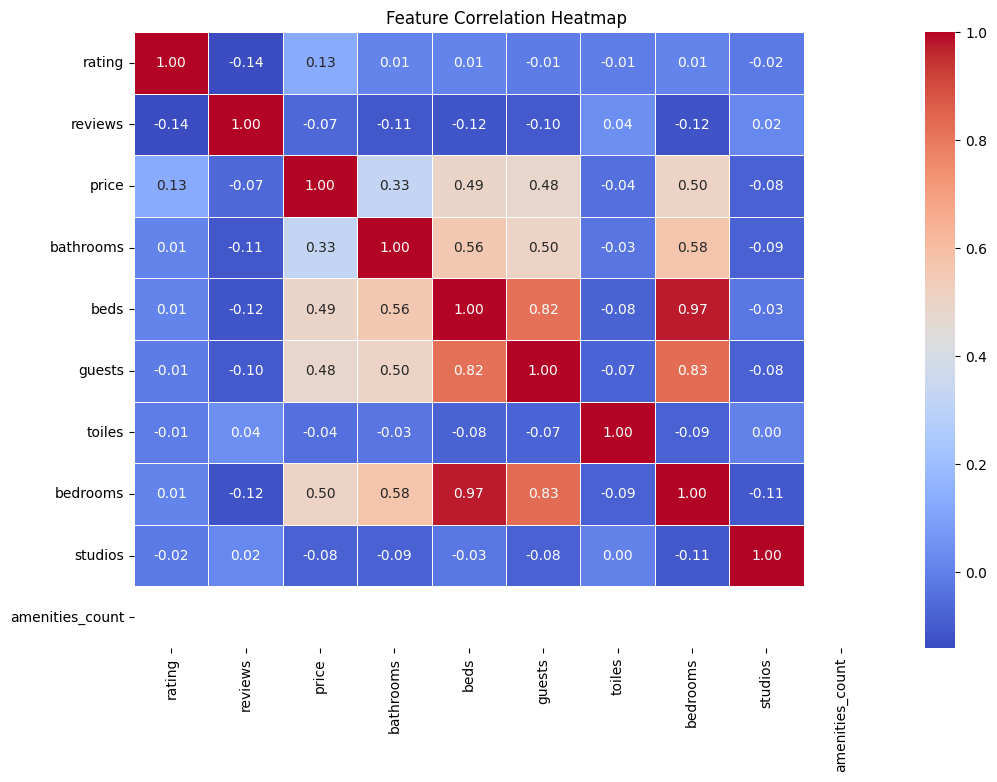

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# One-Hot Encode categorical variables
df_encoded = pd.get_dummies(df, columns=["country"], drop_first=True)

# Select only numerical features for correlation calculation
numerical_features = df_encoded.select_dtypes(include=['number']).columns
df_encoded_numeric = df_encoded[numerical_features]


# Compute correlation matrix for numerical features
corr_matrix = df_encoded_numeric.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [32]:
!pip install xgboost
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Assuming 'df_encoded' is your DataFrame from the previous steps

# Define selected features and target variable
selected_features = ["rating", "reviews", "bathrooms", "beds", "guests", "bedrooms", "amenities_count", ]
X = df_encoded[selected_features]
y = df_encoded["price"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train an XGBoost model
# Note: 'uplift' is typically a separate modeling technique. Here, we're using XGBoost for regression.
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Predictions and evaluation
y_pred_xgb = xgb_model.predict(X_test_scaled)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print the results
print(f"XGBoost MAE: {mae_xgb}")
print(f"XGBoost RMSE: {rmse_xgb}")
print(f"XGBoost R-squared: {r2_xgb}")

KeyError: "['country'] not in index"

In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numerical and categorical features
numerical_features = ["rating", "reviews", "bathrooms", "beds", "guests", "bedrooms", "amenities_count"]
categorical_features = ["country"]

# One-Hot Encode categorical variables
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Transform data
X_processed = preprocessor.fit_transform(df)
y = df["price"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Check transformed feature shape
X_train.shape, X_test.shape


((10244, 155), (2561, 155))

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate performance
mae_lr = mean_absolute_error(y_test, y_pred_lr)
# Calculate RMSE manually using NumPy since 'squared' argument might not be available
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

(mae_lr, rmse_lr, r2_lr)

(5538.550999453514, 7456.583233862014, 0.4546705313308882)

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define an improved ANN model with Leaky ReLU, more layers, and fine-tuning
ann_optimized = keras.Sequential([
    layers.Dense(256, input_shape=(X_train.shape[1],)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1)  # Output layer for regression
])

# Compile model with lower learning rate for better convergence
ann_optimized.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), loss="mse", metrics=["mae"])

# Implement Early Stopping
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# Train model with more epochs
history_optimized = ann_optimized.fit(X_train, y_train, epochs=200, batch_size=42, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Evaluate the optimized model
loss, mae = ann_optimized.evaluate(X_test, y_test, verbose=0)
print(f"Optimized ANN MAE: {mae}")

# Make predictions with the optimized model
y_pred_optimized = ann_optimized.predict(X_test)

# Calculate R-squared for the optimized model
from sklearn.metrics import r2_score
r2_optimized = r2_score(y_test, y_pred_optimized)
print(f"Optimized ANN R-squared: {r2_optimized}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 249661824.0000 - mae: 11923.6562 - val_loss: 233556128.0000 - val_mae: 11474.8223
Epoch 2/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 251766944.0000 - mae: 12024.3096 - val_loss: 233307056.0000 - val_mae: 11471.3105
Epoch 3/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 249215408.0000 - mae: 11957.3926 - val_loss: 232973392.0000 - val_mae: 11464.8145
Epoch 4/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 243706032.0000 - mae: 11768.9414 - val_loss: 232580864.0000 - val_mae: 11457.4287
Epoch 5/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 240125040.0000 - mae: 11736.3018 - val_loss: 232275296.0000 - val_mae: 11451.0742
Epoch 6/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 243409872.0000 - mae: 11825.5127 - val_loss: 231735632.0000 - val_mae: 11437.6865
Epoch 7/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 235444864.0000 - mae: 11594.2715 - val_loss: 231242256.0000 - val_mae: 11427.532

In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Define an optimized ANN model with Swish activation, L2 regularization, and Huber loss
ann_optimized = keras.Sequential([
    layers.Dense(256, input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    layers.Activation(tf.nn.swish),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
    layers.Activation(tf.nn.swish),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
    layers.Activation(tf.nn.swish),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
    layers.Activation(tf.nn.swish),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1)  # Output layer for regression
])

# Compile model with improved learning rate, Huber loss, and Adam optimizer
ann_optimized.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0008, clipnorm=1.0),
                      loss=keras.losses.Huber(delta=1.0), metrics=["mae"])

# Implement Early Stopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# Train model with optimized parameters
history_optimized = ann_optimized.fit(X_train, y_train, epochs=250, batch_size=42,
                                      validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Evaluate the optimized model
loss, mae = ann_optimized.evaluate(X_test, y_test, verbose=0)
print(f"Optimized ANN MAE: {mae}")

# Make predictions with the optimized model
y_pred_optimized = ann_optimized.predict(X_test)

# Calculate R-squared for the optimized model
from sklearn.metrics import r2_score
r2_optimized = r2_score(y_test, y_pred_optimized)
print(f"Optimized ANN R-squared: {r2_optimized}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/250
244/244 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 11852.0254 - mae: 11852.1064 - val_loss: 11471.0771 - val_mae: 11471.2227
Epoch 2/250
244/244 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 11997.2842 - mae: 11997.4385 - val_loss: 11466.0400 - val_mae: 11466.2070
Epoch 3/250
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 11871.6426 - mae: 11871.8135 - val_loss: 11458.1904 - val_mae: 11458.3672
Epoch 4/250
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 11794.3252 - mae: 11794.5068 - val_loss: 11446.8896 - val_mae: 11447.0703
Epoch 5/250
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 11781.7207 - mae: 11781.9082 - val_loss: 11434.3828 - val_mae: 11434.5752
Epoch 6/250
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 11834.3311 - mae: 11834.5254 - val_loss: 11417.6230 - val_mae: 11417.8242
Epoch 7/250
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 11707.5176 - mae: 11707.7217 - val_loss: 11399.8975 - val_mae: 11400.1035
Epoch 8/250
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step -

In [40]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define an improved ANN model with Leaky ReLU, more layers, and fine-tuning
ann_optimized = keras.Sequential([
    layers.Dense(256, input_shape=(X_train.shape[1],)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1)  # Output layer for regression
])

# Compile model with lower learning rate for better convergence
ann_optimized.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), loss="mse", metrics=["mae"])

# Implement Early Stopping
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# Train model with more epochs
history_optimized = ann_optimized.fit(X_train, y_train, epochs=220, batch_size=52, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Evaluate the optimized model
loss, mae = ann_optimized.evaluate(X_test, y_test, verbose=0)
print(f"Optimized ANN MAE: {mae}")

# Make predictions with the optimized model
y_pred_optimized = ann_optimized.predict(X_test)

# Calculate R-squared for the optimized model
from sklearn.metrics import r2_score
r2_optimized = r2_score(y_test, y_pred_optimized)
print(f"Optimized ANN R-squared: {r2_optimized}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/220
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 238831248.0000 - mae: 11685.6689 - val_loss: 233529536.0000 - val_mae: 11472.8701
Epoch 2/220
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 246412000.0000 - mae: 11891.9561 - val_loss: 233391712.0000 - val_mae: 11471.7588
Epoch 3/220
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 245401824.0000 - mae: 11867.2764 - val_loss: 233182336.0000 - val_mae: 11469.6328
Epoch 4/220
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 241250384.0000 - mae: 11716.3174 - val_loss: 232958448.0000 - val_mae: 11465.8301
Epoch 5/220
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 242988848.0000 - mae: 11791.4316 - val_loss: 232698352.0000 - val_mae: 11460.7832
Epoch 6/220
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 244112144.0000 - mae: 11839.7256 - val_loss: 232253168.0000 - val_mae: 11449.8848
Epoch 7/220
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 249630976.0000 - mae: 11985.0625 - val_loss: 231822016.0000 - val_mae: 11440.34

In [41]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import r2_score

# Define an optimized ANN model with Swish activation, L2 regularization, and Huber loss
ann_optimized = keras.Sequential([
    layers.Dense(256, input_shape=(X_train.shape[1],), kernel_regularizer=regularizers.l2(0.001)),
    layers.Activation(tf.nn.swish),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
    layers.Activation(tf.nn.swish),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
    layers.Activation(tf.nn.swish),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)),
    layers.Activation(tf.nn.swish),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1)  # Output layer for regression
])

# Compile model with improved learning rate, Huber loss, and Adam optimizer
ann_optimized.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0008, clipnorm=1.0),
                      loss=keras.losses.Huber(delta=1.0), metrics=["mae"])

# Implement Early Stopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# Train model with optimized parameters
history_optimized = ann_optimized.fit(X_train, y_train, epochs=100, batch_size=32,
                                      validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Evaluate the optimized model
loss, mae = ann_optimized.evaluate(X_test, y_test, verbose=0)
print(f"Optimized ANN MAE: {mae}")

# Make predictions with the optimized model
y_pred_optimized = ann_optimized.predict(X_test)

# Calculate R-squared for the optimized model
r2_optimized = r2_score(y_test, y_pred_optimized)
print(f"Optimized ANN R-squared: {r2_optimized}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 11803.3066 - mae: 11803.3936 - val_loss: 11469.4150 - val_mae: 11469.5576
Epoch 2/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 11696.6543 - mae: 11696.8018 - val_loss: 11461.6699 - val_mae: 11461.8252
Epoch 3/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 11859.7217 - mae: 11859.8887 - val_loss: 11447.9824 - val_mae: 11448.1514
Epoch 4/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 11763.2891 - mae: 11763.4609 - val_loss: 11430.3369 - val_mae: 11430.5166
Epoch 5/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 11659.5449 - mae: 11659.7314 - val_loss: 11408.8691 - val_mae: 11409.0547
Epoch 6/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 11743.7656 - mae: 11743.9502 - val_loss: 11383.8682 - val_mae: 11384.0557
Epoch 7/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 11758.8652 - mae: 11759.0518 - val_loss: 11353.5889 - val_mae: 11353.7783
Epoch 8/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step -

In [43]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Gradient Boosting as base model
gb_model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8)
gb_model.fit(X_train, y_train)

# Get predictions from Gradient Boosting
gb_train_preds = gb_model.predict(X_train).reshape(-1, 1)
gb_test_preds = gb_model.predict(X_test).reshape(-1, 1)

# Append GB predictions as a new feature for ANN training
X_train_ann = np.hstack((X_train, gb_train_preds))
X_test_ann = np.hstack((X_test, gb_test_preds))

# Define ANN model
ann_boosted = keras.Sequential([
    layers.Dense(256, input_shape=(X_train_ann.shape[1],), activation='swish', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation='swish', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='swish', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1)  # Output layer for regression
])

# Compile ANN model
ann_boosted.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0008, clipnorm=1.0),
                    loss=keras.losses.Huber(delta=1.0), metrics=["mae"])

# ... (Previous code for defining and compiling ann_boosted) ...

# Train ANN model
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_boosted = ann_boosted.fit(X_train_ann, y_train, epochs=100, batch_size=32,
                                  validation_data=(X_test_ann, y_test), callbacks=[early_stopping], verbose=1)

# Evaluate model performance
train_mae = ann_boosted.evaluate(X_train_ann, y_train, verbose=0)
test_mae = ann_boosted.evaluate(X_test_ann, y_test, verbose=0)

print(f"Training MAE: {train_mae[1]:.4f}")
print(f"Test MAE: {test_mae[1]:.4f}")

# Make predictions
y_pred = ann_boosted.predict(X_test_ann)

# Convert predictions to original scale if needed
# Assuming 'scaler' is the StandardScaler used to scale the data
y_pred_original = scaler.inverse_transform(y_pred)

# Calculate R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_original)  # Use y_pred_original if it's in the original scale
print(f"R-squared: {r2:.4f}")

# ... (Further analysis or visualization of results) ...


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


321/321 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 11720.2344 - mae: 11720.5166 - val_loss: 11465.5967 - val_mae: 11465.9199
Epoch 2/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 11734.1475 - mae: 11734.4678 - val_loss: 11446.2207 - val_mae: 11446.5488
Epoch 3/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 11791.7754 - mae: 11792.1094 - val_loss: 11427.2178 - val_mae: 11427.5459
Epoch 4/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 11687.8984 - mae: 11688.2256 - val_loss: 11394.4248 - val_mae: 11394.7539
Epoch 5/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 11706.9570 - mae: 11707.2871 - val_loss: 11354.6133 - val_mae: 11354.9453
Epoch 6/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 11731.0801 - mae: 11731.4111 - val_loss: 11307.9980 - val_mae: 11308.3359
Epoch 7/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 11619.6650 - mae: 11619.9961 - val_loss: 11248.9238 - val_mae: 11249.2559
Epoch 8/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1155

ValueError: non-broadcastable output operand with shape (2561,1) doesn't match the broadcast shape (2561,7)